# Лабораторная работа №1: Визуализация данных

**Автор:** Гроза И.В.

## Оглавление и структура работы
В ноутбуке последовательно выполнены все пункты задания:

1. Загрузка и первичный просмотр датасета `weatherAUS.csv`.
2. Краткое описание набора данных, признаков и целевого признака.
3. Визуализации средствами `matplotlib`, включая набор графиков, субграфики и интерактивный график со слайдером.
4. Визуализации средствами `pandas.DataFrame.plot` / `Series.plot`, включая обязательный `boxplot(by=...)`.
5. Визуализации средствами `seaborn`: `pairplot`, `jointplot`, `boxplot`/`violinplot`, `heatmap`.
6. Проверка одного числового признака на близость к нормальному распределению при помощи гистограммы и QQ-графика из `scipy.stats`.
7. Визуализации средствами `plotly`, включая интерактивные графики и субграфики.

Для тяжёлых визуализаций используется подвыборка: это не меняет общие закономерности, но делает графики читаемыми и ускоряет выполнение ноутбука.


## 1. Загрузка данных и подготовка признаков
Загружаю локальный файл `data/weatherAUS.csv`, преобразую дату и добавляю несколько служебных признаков для визуализаций: год, номер месяца и короткую подпись месяца.


In [53]:
from pathlib import Path
import calendar

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
from IPython.display import display
from plotly.subplots import make_subplots
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
pio.renderers.default = "plotly_mimetype"

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
for root in candidate_roots:
    candidate = root / "data" / "weatherAUS.csv"
    if candidate.exists():
        PROJECT_ROOT = root
        DATA_PATH = candidate
        break
else:
    raise FileNotFoundError("Не удалось найти data/weatherAUS.csv")


In [54]:
df = pd.read_csv(DATA_PATH, na_values=["NA"])
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
month_labels = [calendar.month_abbr[i] for i in range(1, 13)]
df["MonthLabel"] = pd.Categorical(
    df["Month"].map(lambda value: calendar.month_abbr[value]),
    categories=month_labels,
    ordered=True,
)
df["RainToday"] = pd.Categorical(df["RainToday"], categories=["No", "Yes"], ordered=True)
df["RainTomorrow"] = pd.Categorical(df["RainTomorrow"], categories=["No", "Yes"], ordered=True)
numeric_cols = df.select_dtypes(include="number").columns.tolist()

df.head()


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,MonthLabel
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,1007.1,8.0,NaN,16.9,21.8,No,No,2008,12,Dec
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,1007.8,NaN,NaN,17.2,24.3,No,No,2008,12,Dec
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,1008.7,NaN,2.0,21.0,23.2,No,No,2008,12,Dec
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,1012.8,NaN,NaN,18.1,26.5,No,No,2008,12,Dec
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,1006.0,7.0,8.0,17.8,29.7,No,No,2008,12,Dec


## 2. Описание датасета
Датасет содержит данные о погодных наблюдениях в Австралии. В работе используется локальная копия `data/weatherAUS.csv`, которая приложена к проекту вместе с ноутбуком. Целевой признак: `RainTomorrow` — будет ли дождь на следующий день.


In [55]:
overview = pd.DataFrame(
    {
        "Параметр": [
            "Количество наблюдений",
            "Количество признаков",
            "Период наблюдений",
            "Количество локаций",
            "Числовые признаки",
            "Категориальные признаки",
        ],
        "Значение": [
            f"{df.shape[0]:,}".replace(",", " "),
            df.shape[1],
            f"{df['Date'].min().date()} — {df['Date'].max().date()}",
            df["Location"].nunique(),
            len(numeric_cols),
            df.select_dtypes(exclude="number").shape[1],
        ],
    }
)

target_distribution = (
    df["RainTomorrow"]
    .value_counts(dropna=False, normalize=True)
    .rename("Доля")
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={"RainTomorrow": "Класс"})
)

missing_share = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
    .rename("Пропуски, %")
    .reset_index()
    .rename(columns={"index": "Признак"})
)

display(overview)
display(target_distribution)
display(missing_share.head(10))


,Параметр,Значение
0,Количество наблюдений,145 460
1,Количество признаков,26
2,Период наблюдений,2007-11-01 — 2017-06-25
3,Количество локаций,49
4,Числовые признаки,18
5,Категориальные признаки,8


,Класс,Доля
0,No,75.84
1,Yes,21.91
2,NaN,2.25


,Признак,"Пропуски, %"
0,Sunshine,48.01
1,Evaporation,43.17
2,Cloud3pm,40.81
3,Cloud9am,38.42
4,Pressure9am,10.36
5,Pressure3pm,10.33
6,WindDir9am,7.26
7,WindGustDir,7.10
8,WindGustSpeed,7.06
9,Humidity3pm,3.10


In [56]:
feature_descriptions = pd.DataFrame(
    [
        ("Date", "Дата наблюдения", "дата"),
        ("Location", "Название метеостанции / локации", "категория"),
        ("MinTemp", "Минимальная температура за последние 24 часа до 9 утра", "°C"),
        ("MaxTemp", "Максимальная температура за последние 24 часа до 9 утра", "°C"),
        ("Rainfall", "Количество осадков за последние 24 часа до 9 утра", "мм"),
        ("Evaporation", "Испарение за последние 24 часа", "мм"),
        ("Sunshine", "Продолжительность яркого солнечного света", "часы"),
        ("WindGustDir", "Направление самого сильного порыва ветра", "категория"),
        ("WindGustSpeed", "Скорость самого сильного порыва ветра", "км/ч"),
        ("WindDir9am", "Направление ветра в 9:00", "категория"),
        ("WindDir3pm", "Направление ветра в 15:00", "категория"),
        ("WindSpeed9am", "Скорость ветра в 9:00", "км/ч"),
        ("WindSpeed3pm", "Скорость ветра в 15:00", "км/ч"),
        ("Humidity9am", "Относительная влажность в 9:00", "%"),
        ("Humidity3pm", "Относительная влажность в 15:00", "%"),
        ("Pressure9am", "Атмосферное давление в 9:00", "гПа"),
        ("Pressure3pm", "Атмосферное давление в 15:00", "гПа"),
        ("Cloud9am", "Облачность в 9:00", "окты (0-8)"),
        ("Cloud3pm", "Облачность в 15:00", "окты (0-8)"),
        ("Temp9am", "Температура в 9:00", "°C"),
        ("Temp3pm", "Температура в 15:00", "°C"),
        ("RainToday", "Был ли дождь сегодня", "Yes/No"),
        ("RainTomorrow", "Будет ли дождь завтра (целевой признак)", "Yes/No"),
    ],
    columns=["Признак", "Описание", "Единицы измерения"],
)

feature_descriptions


,Признак,Описание,Единицы измерения
0,Date,Дата наблюдения,дата
1,Location,Название метеостанции / локации,категория
2,MinTemp,Минимальная температура за последние 24 часа д...,°C
3,MaxTemp,Максимальная температура за последние 24 часа ...,°C
4,Rainfall,Количество осадков за последние 24 часа до 9 утра,мм
5,Evaporation,Испарение за последние 24 часа,мм
6,Sunshine,Продолжительность яркого солнечного света,часы
7,WindGustDir,Направление самого сильного порыва ветра,категория
8,WindGustSpeed,Скорость самого сильного порыва ветра,км/ч
9,WindDir9am,Направление ветра в 9:00,категория


Ключевые наблюдения по описанию данных:

- набор довольно большой: более 145 тысяч наблюдений;
- целевой класс несбалансирован: случаев `No` заметно больше, чем `Yes`;
- больше всего пропусков у `Sunshine`, `Evaporation`, `Cloud9am` и `Cloud3pm`, поэтому при визуализациях нужно явно удалять пропуски по нужным столбцам;
- для анализа связи с целевым признаком особенно интересны влажность, давление, температура и осадки.


## 3. Визуализации средствами matplotlib
Сначала построю несколько графиков разного вида: гистограмму осадков, диаграмму рассеяния температур и столбчатый график доли дождливых дней по месяцам.


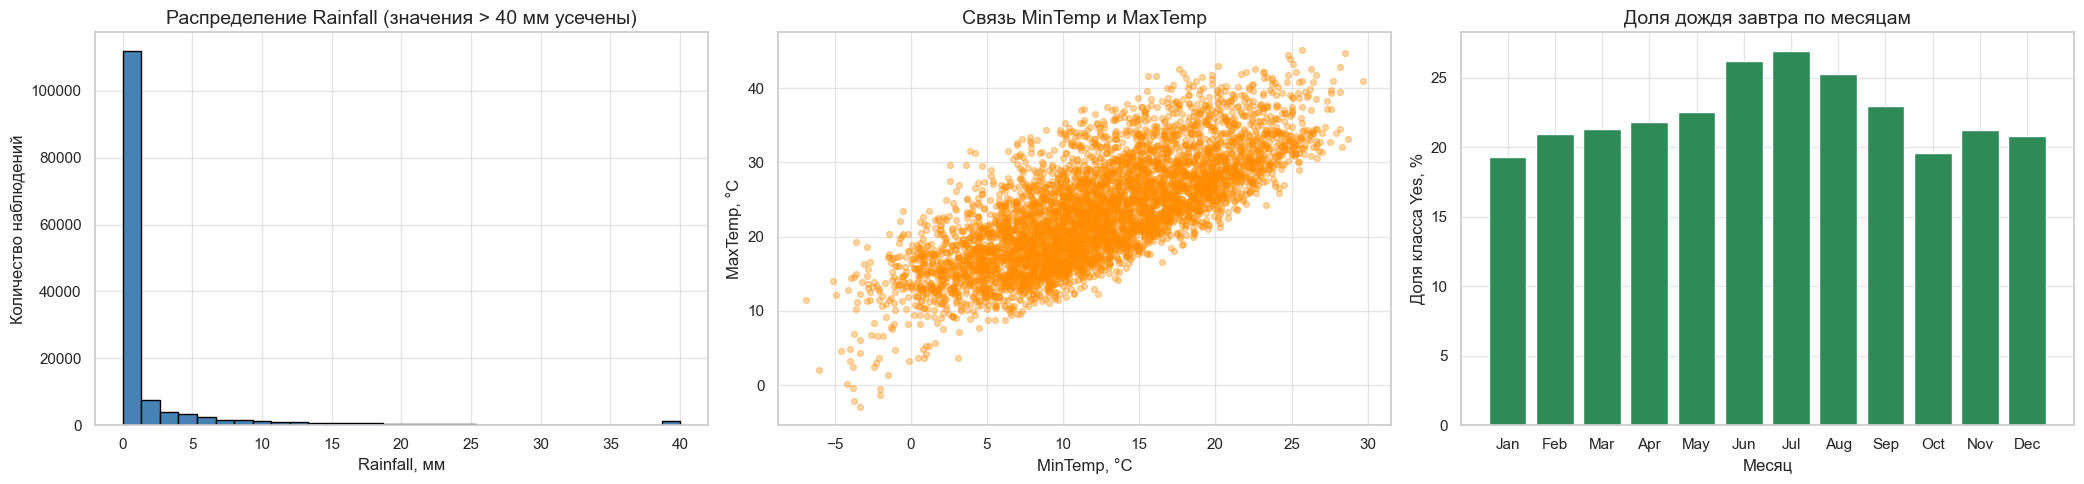

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

rainfall_sample = df["Rainfall"].dropna().clip(upper=40)
axes[0].hist(rainfall_sample, bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Распределение Rainfall (значения > 40 мм усечены)")
axes[0].set_xlabel("Rainfall, мм")
axes[0].set_ylabel("Количество наблюдений")

scatter_sample = df.dropna(subset=["MinTemp", "MaxTemp"]).sample(5000, random_state=42)
axes[1].scatter(scatter_sample["MinTemp"], scatter_sample["MaxTemp"], alpha=0.35, s=18, color="darkorange")
axes[1].set_title("Связь MinTemp и MaxTemp")
axes[1].set_xlabel("MinTemp, °C")
axes[1].set_ylabel("MaxTemp, °C")

rain_share_by_month = (
    df.dropna(subset=["RainTomorrow"])
    .groupby(["Month", "MonthLabel"], observed=False)["RainTomorrow"]
    .apply(lambda values: (values == "Yes").mean() * 100)
    .reset_index(name="RainTomorrowYesShare")
    .sort_values("Month")
)
axes[2].bar(rain_share_by_month["MonthLabel"], rain_share_by_month["RainTomorrowYesShare"], color="seagreen")
axes[2].set_title("Доля дождя завтра по месяцам")
axes[2].set_xlabel("Месяц")
axes[2].set_ylabel("Доля класса Yes, %")

plt.tight_layout()
plt.show()


Далее построю несколько субграфиков на одном полотне через `plt.subplot`, чтобы в одном месте сравнить несколько важных зависимостей.


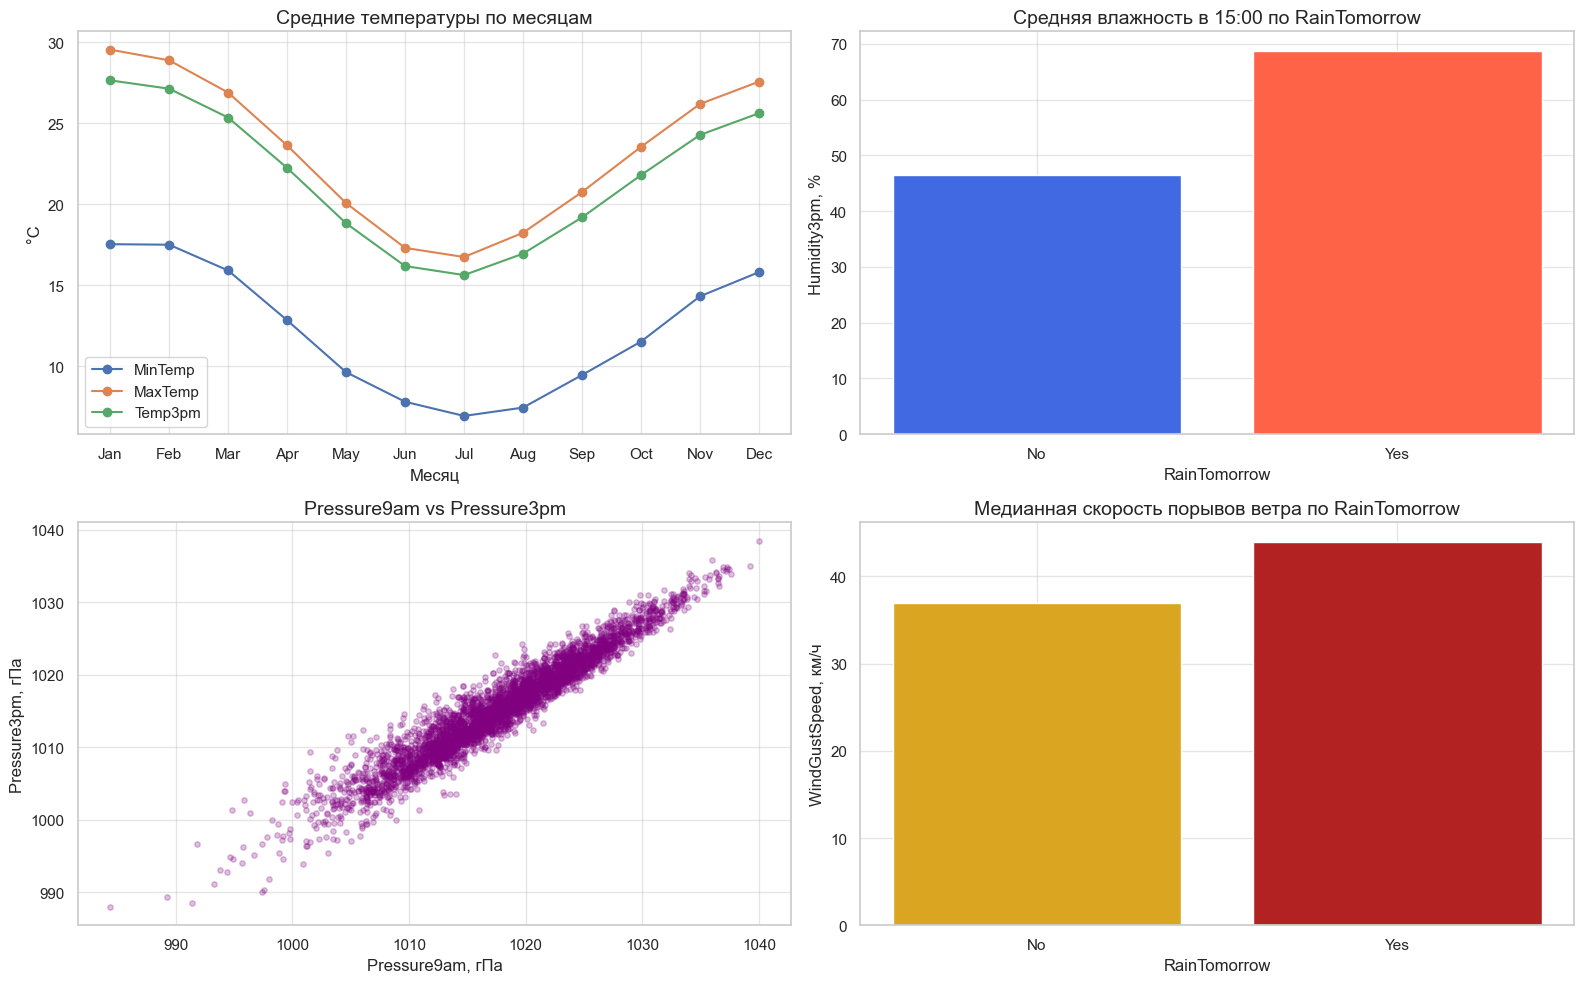

In [58]:
plt.figure(figsize=(16, 10))

monthly_temp = (
    df.groupby("Month", observed=False)[["MinTemp", "MaxTemp", "Temp3pm"]]
    .mean()
    .reset_index()
)
month_ticks = range(1, 13)
month_tick_labels = [calendar.month_abbr[i] for i in month_ticks]

plt.subplot(2, 2, 1)
plt.plot(monthly_temp["Month"], monthly_temp["MinTemp"], marker="o", label="MinTemp")
plt.plot(monthly_temp["Month"], monthly_temp["MaxTemp"], marker="o", label="MaxTemp")
plt.plot(monthly_temp["Month"], monthly_temp["Temp3pm"], marker="o", label="Temp3pm")
plt.title("Средние температуры по месяцам")
plt.xlabel("Месяц")
plt.ylabel("°C")
plt.xticks(month_ticks, month_tick_labels)
plt.legend()

plt.subplot(2, 2, 2)
humidity_by_target = (
    df.dropna(subset=["Humidity3pm", "RainTomorrow"])
    .groupby("RainTomorrow", observed=False)["Humidity3pm"]
    .mean()
)
plt.bar(humidity_by_target.index.astype(str), humidity_by_target.values, color=["royalblue", "tomato"])
plt.title("Средняя влажность в 15:00 по RainTomorrow")
plt.xlabel("RainTomorrow")
plt.ylabel("Humidity3pm, %")

plt.subplot(2, 2, 3)
pressure_sample = df.dropna(subset=["Pressure9am", "Pressure3pm"]).sample(4000, random_state=42)
plt.scatter(pressure_sample["Pressure9am"], pressure_sample["Pressure3pm"], alpha=0.25, s=15, color="purple")
plt.title("Pressure9am vs Pressure3pm")
plt.xlabel("Pressure9am, гПа")
plt.ylabel("Pressure3pm, гПа")

plt.subplot(2, 2, 4)
wind_by_target = (
    df.dropna(subset=["WindGustSpeed", "RainTomorrow"])
    .groupby("RainTomorrow", observed=False)["WindGustSpeed"]
    .median()
)
plt.bar(wind_by_target.index.astype(str), wind_by_target.values, color=["goldenrod", "firebrick"])
plt.title("Медианная скорость порывов ветра по RainTomorrow")
plt.xlabel("RainTomorrow")
plt.ylabel("WindGustSpeed, км/ч")

plt.tight_layout()
plt.show()


Последний пункт для `matplotlib`: интерактивный график со слайдером. Ниже слайдер выбирает год, а на графике показывается среднемесячное количество осадков для пяти самых частых локаций.


In [59]:
top_locations = df["Location"].value_counts().head(5).index.tolist()
rainfall_slider_data = df.dropna(subset=["Rainfall"]).copy()


def plot_rainfall_for_year(year: int) -> None:
    year_data = rainfall_slider_data[
        (rainfall_slider_data["Year"] == year) & (rainfall_slider_data["Location"].isin(top_locations))
        ]
    monthly = (
        year_data.groupby(["Month", "Location"], observed=False)["Rainfall"]
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(11, 6))
    for location in top_locations:
        location_data = monthly[monthly["Location"] == location]
        ax.plot(location_data["Month"], location_data["Rainfall"], marker="o", label=location)

    ax.set_title(f"Средний Rainfall по месяцам, год = {year}")
    ax.set_xlabel("Месяц")
    ax.set_ylabel("Rainfall, мм")
    ax.set_xticks(month_ticks, month_tick_labels)
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
    plt.show()


widgets.interact(
    plot_rainfall_for_year,
    year=widgets.IntSlider(
        value=int(df["Year"].median()),
        min=int(df["Year"].min()),
        max=int(df["Year"].max()),
        step=1,
        description="Год",
    ),
)


interactive(children=(IntSlider(value=2013, description='Год', max=2017, min=2007), Output()), _dom_classes=('…

<function __main__.plot_rainfall_for_year(year: int) -> None>

Вывод по `matplotlib`:

- распределение `Rainfall` сильно скошено вправо: большинство наблюдений близко к нулю, но есть длинный хвост редких сильных осадков;
- между `MinTemp` и `MaxTemp` заметна выраженная положительная зависимость;
- доля класса `RainTomorrow = Yes` различается по месяцам, что указывает на сезонность;
- при `RainTomorrow = Yes` обычно выше влажность и скорость порывов ветра.


## 4. Визуализации средствами pandas
Покажу три разных типа графиков через `DataFrame.plot` / `Series.plot`. В обязательный набор включён `boxplot(by=...)`.


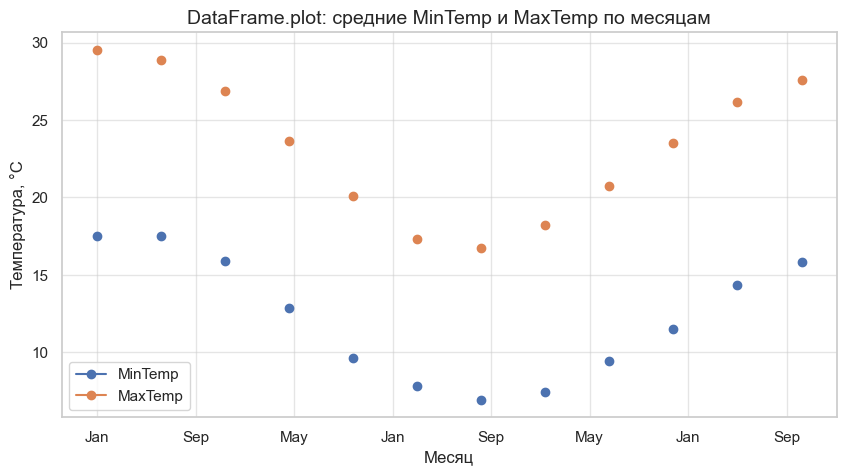

In [60]:
monthly_mean_frame = (
    df.groupby(["Month", "MonthLabel"], observed=False)[["MinTemp", "MaxTemp"]]
    .mean()
    .reset_index()
    .sort_values("Month")
)

ax = monthly_mean_frame.plot(
    x="MonthLabel",
    y=["MinTemp", "MaxTemp"],
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="DataFrame.plot: средние MinTemp и MaxTemp по месяцам",
)
ax.set_xlabel("Месяц")
ax.set_ylabel("Температура, °C")
plt.show()


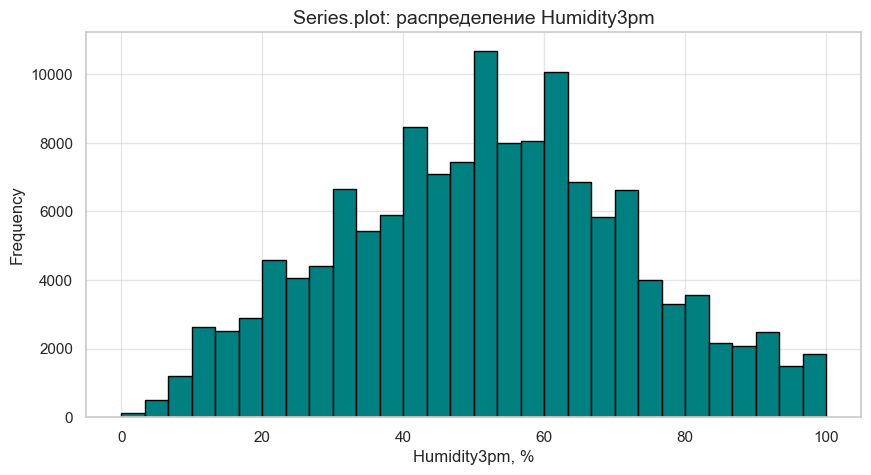

In [61]:
ax = (
    df["Humidity3pm"]
    .dropna()
    .plot(
        kind="hist",
        bins=30,
        color="teal",
        edgecolor="black",
        figsize=(10, 5),
        title="Series.plot: распределение Humidity3pm",
    )
)
ax.set_xlabel("Humidity3pm, %")
plt.show()


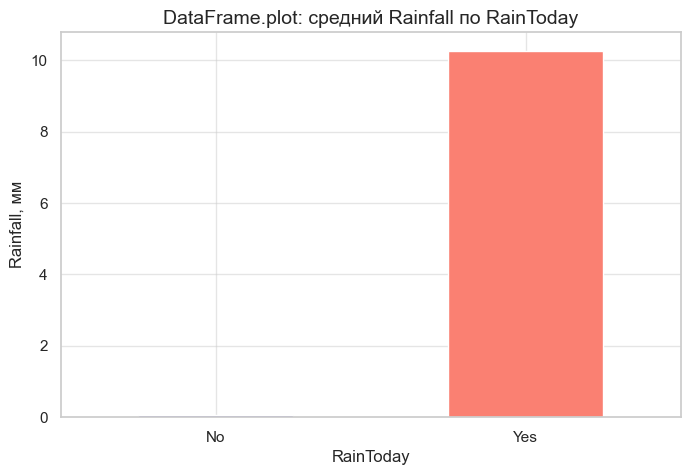

In [62]:
rain_today_share = (
    df.dropna(subset=["RainToday"])
    .groupby("RainToday", observed=False)["Rainfall"]
    .mean()
    .rename("MeanRainfall")
    .reset_index()
)

ax = rain_today_share.plot(
    x="RainToday",
    y="MeanRainfall",
    kind="bar",
    color=["slateblue", "salmon"],
    legend=False,
    figsize=(8, 5),
    title="DataFrame.plot: средний Rainfall по RainToday",
)
ax.set_xlabel("RainToday")
ax.set_ylabel("Rainfall, мм")
plt.xticks(rotation=0)
plt.show()


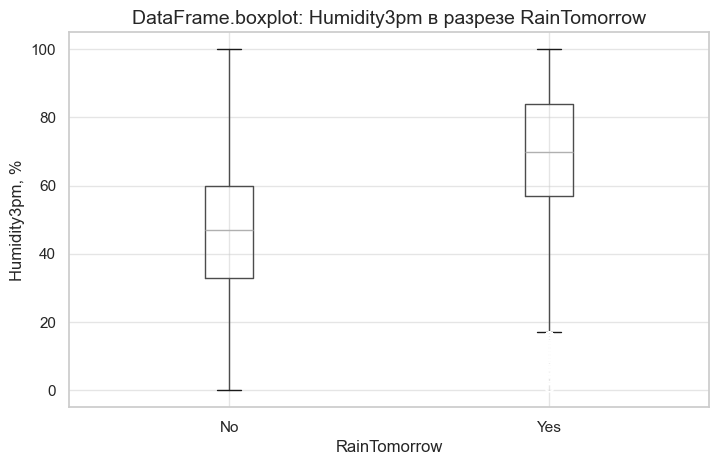

In [63]:
ax = df.dropna(subset=["Humidity3pm", "RainTomorrow"]).boxplot(
    column="Humidity3pm",
    by="RainTomorrow",
    figsize=(8, 5),
)
ax.set_title("DataFrame.boxplot: Humidity3pm в разрезе RainTomorrow")
ax.set_xlabel("RainTomorrow")
ax.set_ylabel("Humidity3pm, %")
plt.suptitle("")
plt.show()


Вывод по графикам `pandas`:

- температурные ряды по месяцам подтверждают сезонный характер набора данных;
- распределение `Humidity3pm` выглядит широким и несимметричным;
- среднее количество осадков заметно выше для записей с `RainToday = Yes`;
- `boxplot` показывает, что при `RainTomorrow = Yes` уровень влажности в 15:00, как правило, выше.


## 5. Визуализации средствами seaborn
Для `seaborn` последовательно строю `pairplot`, `jointplot`, `boxplot`/`violinplot` и тепловую карту корреляций.


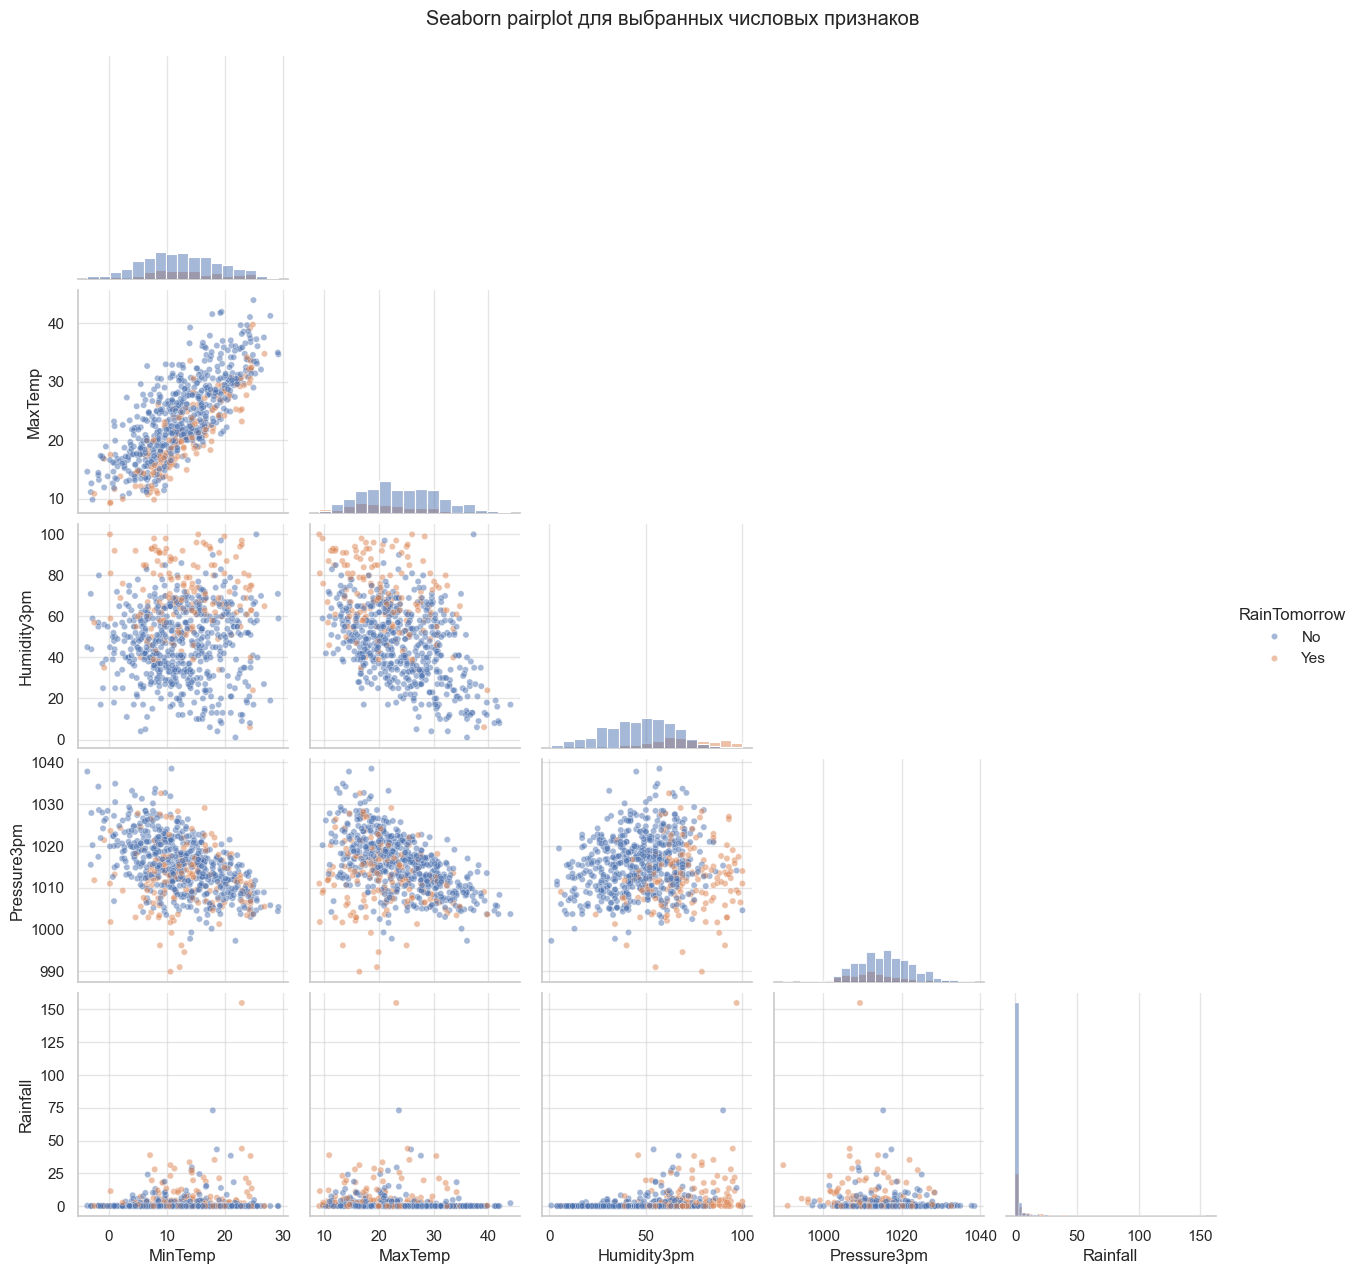

In [64]:
pairplot_columns = ["MinTemp", "MaxTemp", "Humidity3pm", "Pressure3pm", "Rainfall", "RainTomorrow"]
pairplot_df = df.dropna(subset=pairplot_columns).sample(700, random_state=42)

pair_grid = sns.pairplot(
    pairplot_df,
    vars=["MinTemp", "MaxTemp", "Humidity3pm", "Pressure3pm", "Rainfall"],
    hue="RainTomorrow",
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.5, "s": 20},
)
pair_grid.fig.suptitle("Seaborn pairplot для выбранных числовых признаков", y=1.02)
plt.show()


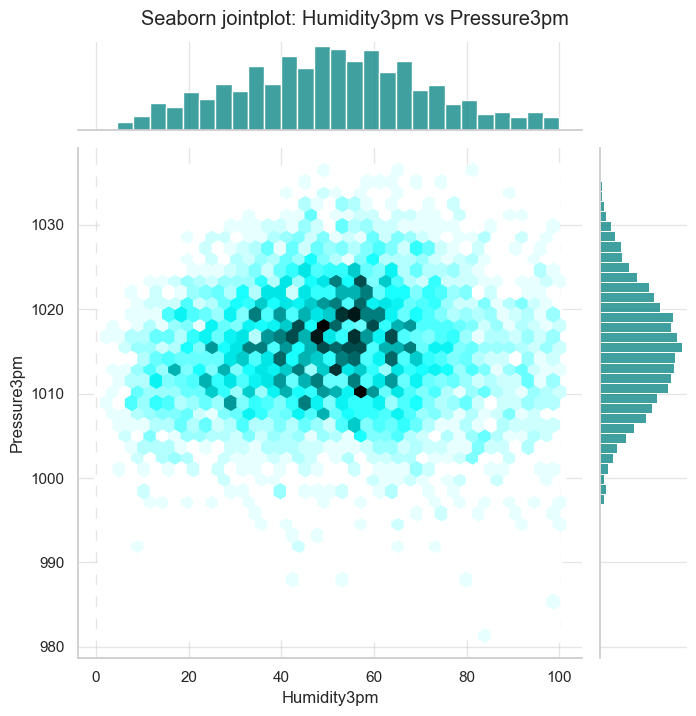

In [65]:
jointplot_df = df.dropna(subset=["Humidity3pm", "Pressure3pm"]).sample(4000, random_state=42)
joint_grid = sns.jointplot(
    data=jointplot_df,
    x="Humidity3pm",
    y="Pressure3pm",
    kind="hex",
    height=7,
    color="teal",
)
joint_grid.fig.suptitle("Seaborn jointplot: Humidity3pm vs Pressure3pm", y=1.02)
plt.show()


C:\Users\Марина\AppData\Local\Temp\ipykernel_14140\3680347945.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=seaborn_box_df, x="RainTomorrow", y="Humidity3pm", ax=axes[0], palette="Set2")
C:\Users\Марина\AppData\Local\Temp\ipykernel_14140\3680347945.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=seaborn_box_df, x="RainTomorrow", y="WindGustSpeed", ax=axes[1], palette="pastel")


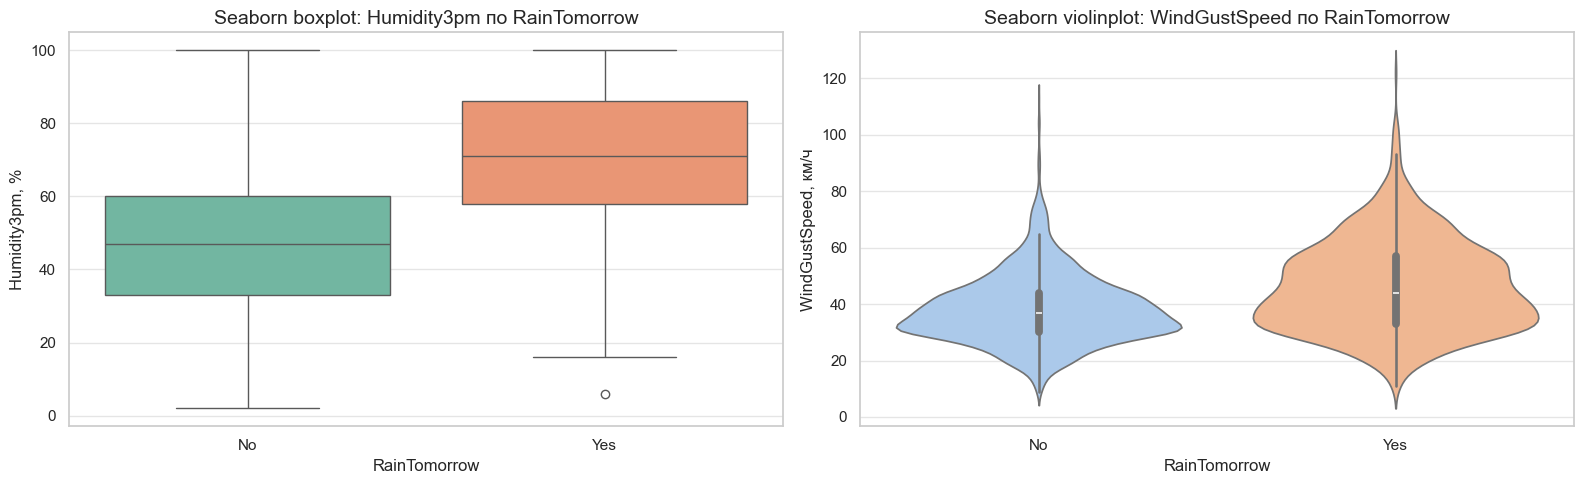

In [66]:
seaborn_box_df = df.dropna(subset=["Humidity3pm", "RainTomorrow"]).sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=seaborn_box_df, x="RainTomorrow", y="Humidity3pm", ax=axes[0], palette="Set2")
axes[0].set_title("Seaborn boxplot: Humidity3pm по RainTomorrow")
axes[0].set_xlabel("RainTomorrow")
axes[0].set_ylabel("Humidity3pm, %")

sns.violinplot(data=seaborn_box_df, x="RainTomorrow", y="WindGustSpeed", ax=axes[1], palette="pastel")
axes[1].set_title("Seaborn violinplot: WindGustSpeed по RainTomorrow")
axes[1].set_xlabel("RainTomorrow")
axes[1].set_ylabel("WindGustSpeed, км/ч")

plt.tight_layout()
plt.show()


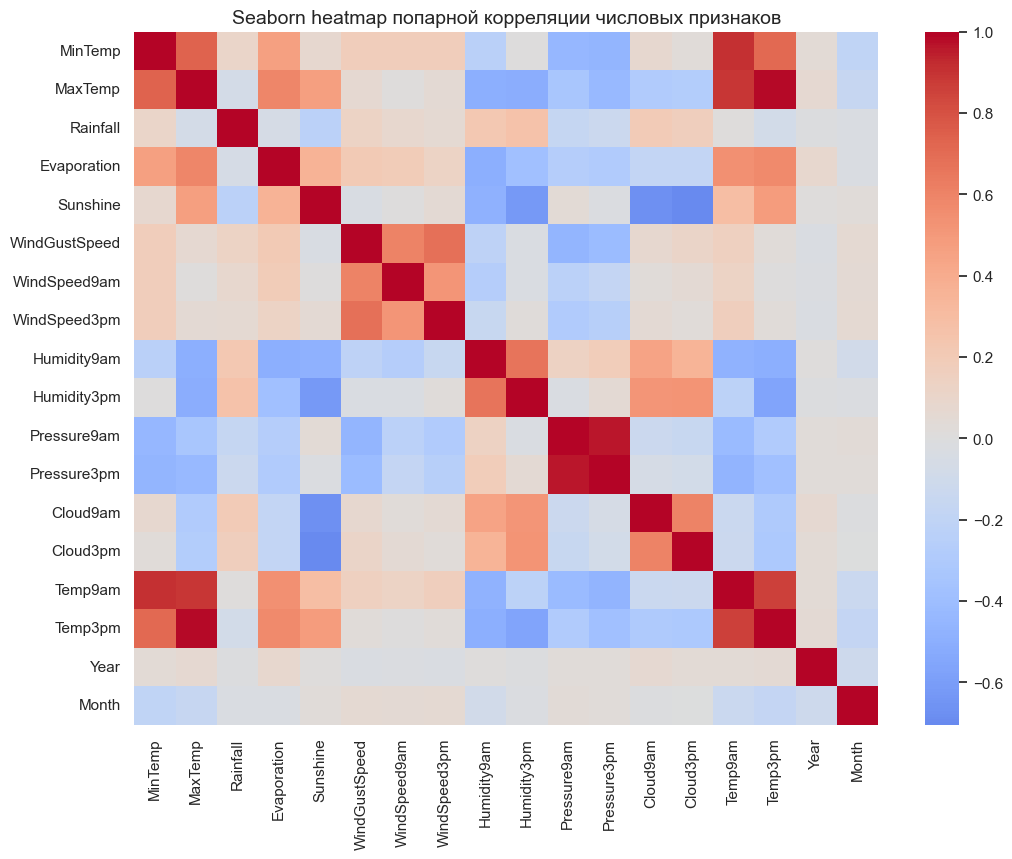

In [67]:
correlation_matrix = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Seaborn heatmap попарной корреляции числовых признаков")
plt.show()


Вывод по `seaborn`:

- `pairplot` показывает сильные положительные связи между температурными признаками и заметную связь осадков/влажности с целевым классом;
- `jointplot` демонстрирует, что при росте влажности давление чаще оказывается ниже;
- `boxplot` и `violinplot` подтверждают, что для дождливого следующего дня характерны более высокая влажность и более сильные порывы ветра;
- `heatmap` показывает ожидаемо высокую корреляцию между `Temp9am`, `Temp3pm`, `MinTemp`, `MaxTemp`, а также между утренним и дневным давлением.


## 6. QQ-график и гистограмма через scipy.stats
Для проверки на близость к нормальному распределению возьму признак `Pressure3pm`: он выглядит более подходящим для такой проверки, чем, например, `Rainfall`, у которого очень сильная асимметрия.


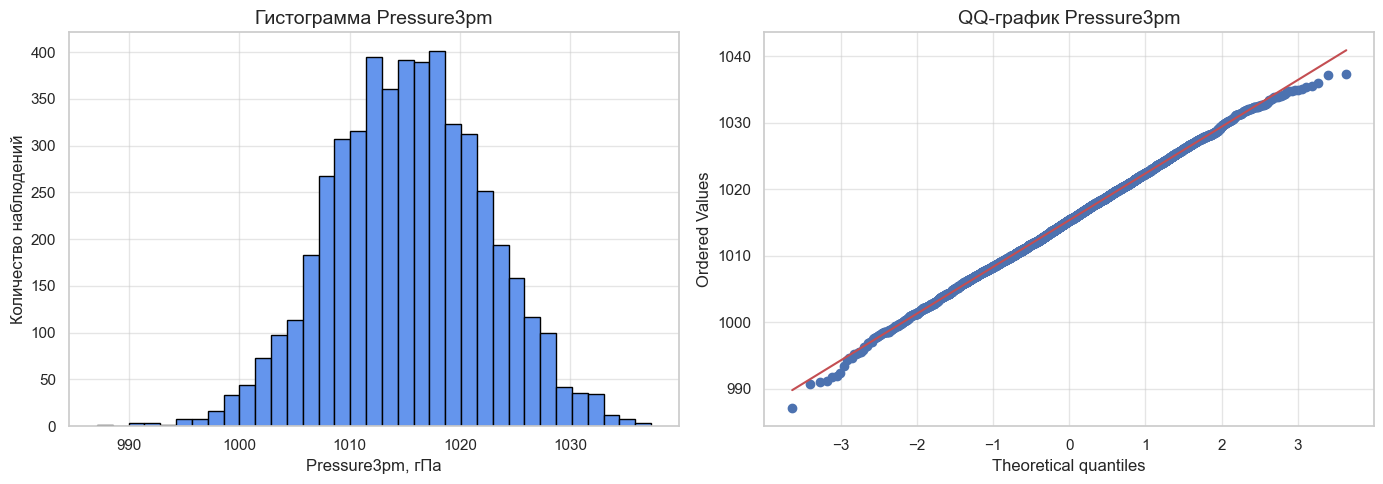

Статистика normaltest: 0.626
p-value normaltest: 0.731398


In [68]:
pressure_series = df["Pressure3pm"].dropna()
sampled_pressure = pressure_series.sample(5000, random_state=42)
normality_stat, normality_pvalue = stats.normaltest(sampled_pressure)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sampled_pressure, bins=35, color="cornflowerblue", edgecolor="black")
axes[0].set_title("Гистограмма Pressure3pm")
axes[0].set_xlabel("Pressure3pm, гПа")
axes[0].set_ylabel("Количество наблюдений")

stats.probplot(sampled_pressure, dist="norm", plot=axes[1])
axes[1].set_title("QQ-график Pressure3pm")

plt.tight_layout()
plt.show()

print(f"Статистика normaltest: {normality_stat:.3f}")
print(f"p-value normaltest: {normality_pvalue:.6g}")


Вывод по проверке на нормальность:

- гистограмма `Pressure3pm` ближе к колоколообразной форме, чем многие другие признаки датасета;
- на QQ-графике центральная часть лежит сравнительно близко к прямой, но в хвостах заметны отклонения;
- это означает, что распределение можно считать лишь приближённо нормальным в центре, но не строго нормальным по всей выборке.


## 7. Визуализации средствами plotly
`plotly` по умолчанию даёт интерактивность, поэтому здесь удобно показать несколько разных типов графиков, субграфики и отдельный график с ползунком диапазона по оси времени.


In [69]:
plotly_scatter_df = df.dropna(subset=["MinTemp", "MaxTemp", "RainTomorrow"]).sample(3000, random_state=42)
fig_scatter = px.scatter(
    plotly_scatter_df,
    x="MinTemp",
    y="MaxTemp",
    color="RainTomorrow",
    opacity=0.55,
    title="Plotly scatter: MinTemp vs MaxTemp",
    hover_data=["Location", "RainToday"],
)
fig_scatter.update_layout(legend_title_text="RainTomorrow")
fig_scatter


In [70]:
plotly_box_df = df.dropna(subset=["Humidity3pm", "RainTomorrow"]).sample(4000, random_state=42)
fig_box = px.box(
    plotly_box_df,
    x="RainTomorrow",
    y="Humidity3pm",
    color="RainTomorrow",
    title="Plotly boxplot: Humidity3pm по RainTomorrow",
)
fig_box.update_layout(showlegend=False)
fig_box


In [71]:
monthly_plotly = (
    df.groupby("Month", observed=False)
    .agg(
        MeanMaxTemp=("MaxTemp", "mean"),
        MeanRainfall=("Rainfall", "mean"),
        MeanHumidity3pm=("Humidity3pm", "mean"),
    )
    .reset_index()
)

fig_subplots = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Температура и влажность по месяцам", "Средний Rainfall по месяцам"),
)

fig_subplots.add_trace(
    go.Scatter(
        x=month_tick_labels,
        y=monthly_plotly["MeanMaxTemp"],
        mode="lines+markers",
        name="MeanMaxTemp",
    ),
    row=1,
    col=1,
)
fig_subplots.add_trace(
    go.Scatter(
        x=month_tick_labels,
        y=monthly_plotly["MeanHumidity3pm"],
        mode="lines+markers",
        name="MeanHumidity3pm",
        yaxis="y2",
    ),
    row=1,
    col=1,
)
fig_subplots.add_trace(
    go.Bar(
        x=month_tick_labels,
        y=monthly_plotly["MeanRainfall"],
        name="MeanRainfall",
        marker_color="seagreen",
    ),
    row=1,
    col=2,
)

fig_subplots.update_layout(
    title_text="Plotly subplots для ключевых агрегатов по месяцам",
    height=500,
)
fig_subplots


In [72]:
daily_plotly = (
    df.groupby("Date", observed=False)[["MinTemp", "MaxTemp", "Rainfall"]]
    .mean()
    .reset_index()
)

fig_line = px.line(
    daily_plotly,
    x="Date",
    y=["MinTemp", "MaxTemp"],
    title="Интерактивный Plotly-график средних дневных температур",
)
fig_line.update_layout(hovermode="x unified")
fig_line.update_xaxes(rangeslider_visible=True)
fig_line


Вывод по `plotly`:

- интерактивные графики удобно использовать для просмотра плотных данных и подсказок по отдельным точкам;
- scatter ещё раз подтверждает тесную связь `MinTemp` и `MaxTemp`;
- boxplot по влажности повторяет вывод предыдущих разделов: дождливый следующий день связан с более высокой влажностью;
- субграфики и график с диапазонным слайдером помогают анализировать сезонность и динамику признаков во времени.


## Итоговый вывод
На датасете `weatherAUS.csv` выполнены все требуемые визуализации. По графикам видно, что:

- погодные признаки имеют выраженную сезонность;
- температура, влажность, давление и осадки связаны между собой неслучайно;
- для класса `RainTomorrow = Yes` характерны более высокая влажность, более сильные порывы ветра и, как правило, иная структура давления;
- распределения части числовых признаков далеки от нормальных, особенно у осадков, тогда как давление выглядит ближе к нормальному только в центральной части.

Следовательно, датасет хорошо подходит для разведочного анализа и последующего построения моделей прогноза дождя.
